# 0. Установка # Обновление пакета geomml 

In [1]:
from pathlib import Path
import os

root = Path(os.getcwd()).resolve().parents[1]  # вверх на 2 уровня
!python {str(root / "scripts" / "bootstrap.py")}

%load_ext autoreload
%autoreload 2

from hydra import initialize_config_dir, compose
from hydra.utils import instantiate

config_name = "default"

with initialize_config_dir(config_dir=str(root / "configs"), version_base="1.3"):
    cfg = compose(config_name=config_name)

# При начальной установке и запуске может не сработать, нужно перезапустить. Бага в разработке, пока не исправлена. 


Obtaining file:///C:/Users/goryachev/source/repos/_DLS/_Sem_01/project-GeomML
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for geomml (pyproject.toml): started
  Building editable for geomml (pyproject.toml): finished with status 'done'
  Created wheel for geomml: filename=geomml-0.1-0.editable-py3-none-any.whl size=1275 sha256=1d26ffde472e6854d481f91defa73cd3c462bae33fd1914479c6ea7992575235
  Stored in directory: C:\Users\goryachev\AppData\Local\Temp\pip-ephem-wheel-cache-3736nxyh\wheels\6f\f2\47\28fea954ad78788e771b12c843

In [4]:
import torch.nn.functional as F
from torch_geometric.loader import DataLoader

from geomml.utils.device import *
from geomml.losses.dipol_polar import loss as dipol_polar_loss
from geomml.models import build as build_model
from geomml.datasets import build as build_dataset
from geomml.utils.loader import build as build_loaders
from geomml.utils.plot_history import *
from geomml.trainers.multi_task import MultiTaskTrainer

%matplotlib inline

# 1. Постановка задачи

Улучшение предсказаний вектора дипольного момента (и тензора поляризуемости) молекул датасета Alchemy с использованием GeomML + TDA

# 2. Базовая модель
Здесь модель должна получать два источника информации:
1. GeomML (или EGNN/SchNet/GeoGNN) — геометрия молекулы. Геометрический энкодер --- ```GeomEncoder -> (B,D)```.
2. TDA-признаки (persistent homology) — топологические признаки молекулы.  TDA encoder - обычный MLP.



То есть это уже двухветочная сеть:


  ```mermaid
flowchart TB

subgraph Geometry
A[Атомные номера + 3D-координаты]
B[GeomML]
C[Геометрический эмбеддинг]
A --> B --> C
end

subgraph Topology
D[TDA-признаки]
E[TDA Encoder]
D --> E
end

C --> F[Конкатенация признаков Feature Fusion]
E --> F

F --> G[Fusion MLP / MLP Head]

G --> H[Дипольный момент μ]
G --> I[Тензор поляризуемости α]
```





Поэтому полностью копировать код QM9 нельзя.

# Я бы построил пайплайн так
```
project/

data/
    Alchemy/

datasets.py
tda_features.py
model.py
train.py
evaluate.py
utils.py
```

# Interface-Contract between dataset---collate

Датасет возвращает
```
{
    "z": ...,
    "pos": ...,
    "tda": ...,          # вектор TDA признаков
    "dipole": ...,       # (3,)
    "polar": ...         # (6,) или (3x3)
}
```
collate принимает
```
return (
    z,
    pos,
    mask,
    tda,
    dipole,
    polar
)
```


# Fusion
```mermaid
flowchart TB

subgraph Feature Extraction
A[Geometric Embedding]
B[Topological Embedding]
end

A --> C[Feature Fusion]
B --> C

C --> D["Concatenated Representation<br/>(256-d)"]

D --> E[Regression MLP]
```

# Head

Если одновременно предсказываются
* μ=(μx,μy,μz)
* α, 
 то ```Linear(256,128) -> ReLU -> Linear(128,9)```

Например:
  - 3 → диполь
  - 6 → поляризуемость

# train_epoch
Практически такой же

In [ ]:
for z,pos,mask,tda,dipole,polar in train_loader:

    pred_mu,pred_alpha=model(
        z,
        pos,
        mask,
        tda
    )

    loss_mu=criterion(pred_mu,dipole)

    loss_alpha=criterion(pred_alpha,polar)

    loss=loss_mu+0.5*loss_alpha

# evaluate

Тоже почти без изменений: ```MAE(mu) -> MAE(alpha) -> MSE(mu) -> MSE(alpha)```

# Что нужно добавить по сравнению с QM9

Самое большое отличие — TDA-признаки. Нужно заранее вычислить их.

Например
```
tda_features.npy

shape

(N,128)
```
или
```
(N,64)
```
Тогда Dataset просто делает:

In [ ]:
tda=torch.from_numpy(
    self.tda[idx]
)

# Если цель — именно дипломная работа, я бы предложил более современную архитектуру:
 Такой подход заметно сильнее простого объединения признаков (torch.cat) и выглядит более современно для дипломной работы, поскольку использует отдельные энкодеры для геометрии и топологии, а затем объединяет их представления перед предсказанием физических свойств молекулы.
```mermaid
flowchart TB

subgraph Geometry Branch
A[Atomic Coordinates]
B[EGNN / GeomML]
C[256-dimensional Molecular Embedding]

A --> B --> C
end

subgraph Topology Branch
D[Persistent Diagrams]
E[PersLay / Persistence Image]
F[128-dimensional Topological Embedding]

D --> E --> F
end

C --> G[Cross Attention]
F --> G

G --> H[Fusion MLP]

H --> I[Dipole Moment μ]
H --> J[Polarizability Tensor α]
```



#====================================================================================================================

Я бы немного уточнил архитектуру, чтобы она была логичной с точки зрения современных GNN и методов TDA. Например, PersLay обычно работает не с самими диаграммами, а с их векторным представлением, а после Cross Attention имеет смысл выполнить объединение признаков и уже затем предсказывать свойства.




# 1. Геометрическая ветвь
Использует (1).**типы атомов**, (2).**координаты**, (3).**расстояния между атомами**, (4).**соседние связи**. На выходе получается эмбеддинг  ``` h_geom ∈ ℝ²⁵⁶``` всей молекулы.


#  2. Топологическая ветвь
Из координат молекулы строится фильтрация (например, Vietoris–Rips или Alpha Complex), затем вычисляются диаграммы персистентности. PersLay или Persistence Image преобразует их в фиксированный вектор ```h_tda ∈ ℝ¹²⁸```.

# 3. Cross Attention
Вместо простого ```torch.cat()``` используется механизм внимания. Например,
```
Query  ← h_geom

Key    ← h_tda

Value  ← h_tda
```
Благодаря этому геометрический эмбеддинг «обращает внимание» только на наиболее информативные топологические признаки.

Получается ```h_fused```

# 4. Feature Fusion
После внимания признаки объединяются
```h = [h_geom ; h_fused]```
или
```h = Linear([h_geom ; h_fused])```


# 5. Общая голова ```Fusion MLP``` 
из объединённого представления строит скрытые признаки. То есть две независимые регрессионные головы.

# Почему такая архитектура лучше простого torch.cat

Если просто объединить признаки,
```
[h_geom ; h_tda]
```
то модель сама должна понять, какие топологические признаки полезны.

Cross Attention позволяет сделать это явно:
* геометрия направляет внимание на важные топологические признаки;
* неинформативные TDA-компоненты получают меньший вес;
* повышается интерпретируемость модели.

# Я бы предложил ещё более современный вариант
Сейчас многие архитектуры используют не один блок внимания, а небольшую последовательность:



Архитектуру можно представить так:




```mermaid
flowchart TB

%% =========================
%% Geometry branch
%% =========================
subgraph Geometry Branch
    A[Atomic Numbers + 3D Coordinates]
    B[EGNN / GeomML Encoder]
    C[Geometric Embedding<br/>256-d : h_geom ∈ ℝ²⁵⁶]

    A --> B --> C
end

%% =========================
%% Topology branch
%% =========================
subgraph Topology Branch
    D[Persistent Diagrams]
    E[PersLay / Persistence Image Encoder]
    F[Topological Embedding<br/>128-d : h_tda ∈ ℝ¹²⁸]

    D --> E --> F
end

%% =========================
%% Fusion block
%% =========================
C --> G[Multi-Head Cross Attention]
F --> G

subgraph Feature Fusion
    H[Layer Normalization]
    I[Residual Connection]
    H --> I
end
G --> H


I --> J[Fusion MLP]

%% =========================
%% Outputs
%% =========================
subgraph Outputs
    K[Dipole Head<br/>μ ∈ ℝ³] 
    KK[Dipole Moment μx,μy,μz Regression]
    
    L[Polarizability Head<br/>α ∈ ℝ⁶ / 3×3]
    LL[Polarizability Tensor α Regression]
end
J --> K --> KK
J --> L --> LL 
```


Такой вариант выглядит современнее, поскольку включает элементы, характерные для трансформеров (многоголовое внимание, остаточные связи и нормализацию), но при этом остаётся достаточно компактным и реалистичным для реализации в рамках проекта или дипломной работы.

## 2. Cравнение двух режимов обучения одного и того же multi-task GNN, 
где различаются только **loss-функции** (а косвенно — динамика оптимизации и баланс градиентов).


Dataset size: 173086

Epoch [   1/1000] | TrainLoss: 1.0163 | ValidLoss: 0.9072 | LR: 1.00e-03 | EarlyStop: 0 /15 | EpochTime: 41.82s
Epoch [   2/1000] | TrainLoss: 0.8521 | ValidLoss: 0.8800 | LR: 1.00e-03 | EarlyStop: 0 /15 | EpochTime: 23.91s
Epoch [   3/1000] | TrainLoss: 0.8201 | ValidLoss: 0.8190 | LR: 1.00e-03 | EarlyStop: 0 /15 | EpochTime: 23.64s
Epoch [   4/1000] | TrainLoss: 0.7924 | ValidLoss: 0.7933 | LR: 1.00e-03 | EarlyStop: 0 /15 | EpochTime: 24.15s
Epoch [   5/1000] | TrainLoss: 0.7637 | ValidLoss: 0.7662 | LR: 1.00e-03 | EarlyStop: 0 /15 | EpochTime: 24.01s
Epoch [   6/1000] | TrainLoss: 0.7399 | ValidLoss: 0.7474 | LR: 1.00e-03 | EarlyStop: 0 /15 | EpochTime: 23.82s
Epoch [   7/1000] | TrainLoss: 0.7234 | ValidLoss: 0.7290 | LR: 1.00e-03 | EarlyStop: 0 /15 | EpochTime: 24.07s
Epoch [   8/1000] | TrainLoss: 0.7052 | ValidLoss: 0.7087 | LR: 1.00e-03 | EarlyStop: 0 /15 | EpochTime: 23.79s
Epoch [   9/1000] | TrainLoss: 0.6794 | ValidLoss: 0.6893 | LR: 1.00e-03 | EarlyS

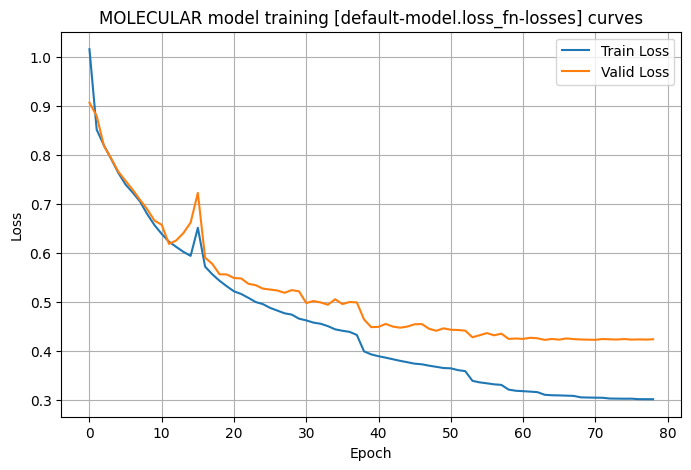

In [ ]:
qm9 = build_dataset("qm9", target_index=4)
esol = build_dataset("esol")
ogbg_molhiv = build_dataset("ogbg-molhiv")

dataset = build_dataset( # Получение --- Скачивание датасета
    "unified",
    datasets=[qm9, esol, ogbg_molhiv]
)

loaders = build_loaders( # Разделение train/val/test # Подготовка DataLoader'ов
    dataset, 
    batch_size=64,
    train_size=0.8,
    valid_size=0.1,
)

model = build_model("molecular", n_features=128)
optimizer = instantiate(cfg.optimizer, params=model.parameters())
scheduler = instantiate(cfg.scheduler, optimizer)

trainer = MultiTaskTrainer(
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    #criterion = default model.loss_fn(...)
    device=get_device(),
    patience=15,
    min_delta=1e-4,
    best_model_pfx="default_loss_fn",
)

model, history = trainer.fit(
    train_loader=loaders.train,
    valid_loader=loaders.valid,
    num_epochs=1000
)

plot_history(history, title="MOLECULAR model training [default-model.loss_fn-losses] curves")

del optimizer, model, trainer, history, loaders, dataset, qm9, esol, ogbg_molhiv



Dataset size: 173086

Epoch [   1/1000] | TrainLoss: 0.7648 | ValidLoss: 0.6824 | LR: 1.00e-03 | EarlyStop: 0 /15 | EpochTime: 42.08s
Epoch [   2/1000] | TrainLoss: 0.6894 | ValidLoss: 0.7170 | LR: 1.00e-03 | EarlyStop: 1 /15 | EpochTime: 23.46s
Epoch [   3/1000] | TrainLoss: 0.6724 | ValidLoss: 0.6535 | LR: 1.00e-03 | EarlyStop: 0 /15 | EpochTime: 26.96s
Epoch [   4/1000] | TrainLoss: 0.6569 | ValidLoss: 0.6830 | LR: 1.00e-03 | EarlyStop: 1 /15 | EpochTime: 29.13s
Epoch [   5/1000] | TrainLoss: 0.6442 | ValidLoss: 0.6354 | LR: 1.00e-03 | EarlyStop: 0 /15 | EpochTime: 26.16s
Epoch [   6/1000] | TrainLoss: 0.6269 | ValidLoss: 0.6183 | LR: 1.00e-03 | EarlyStop: 0 /15 | EpochTime: 27.76s
Epoch [   7/1000] | TrainLoss: 0.6147 | ValidLoss: 0.6313 | LR: 1.00e-03 | EarlyStop: 1 /15 | EpochTime: 26.85s
Epoch [   8/1000] | TrainLoss: 0.6052 | ValidLoss: 0.5940 | LR: 1.00e-03 | EarlyStop: 0 /15 | EpochTime: 24.80s
Epoch [   9/1000] | TrainLoss: 0.5920 | ValidLoss: 0.6083 | LR: 1.00e-03 | EarlyS

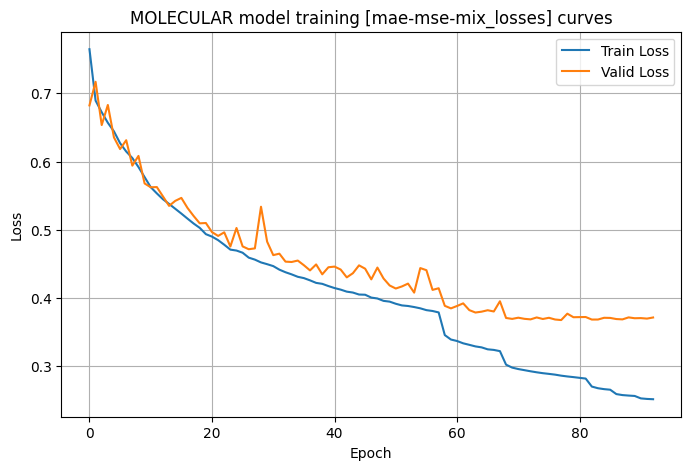

In [ ]:
from geomml.losses.multi_task import multitask_loss

qm9 = build_dataset("qm9", target_index=4)
esol = build_dataset("esol")
ogbg_molhiv = build_dataset("ogbg-molhiv")

dataset = build_dataset( # Получение --- Скачивание датасета
    "unified",
    datasets=[qm9, esol, ogbg_molhiv]
)

loaders = build_loaders( # Разделение train/val/test # Подготовка DataLoader'ов
    dataset, 
    batch_size=64,
    train_size=0.8,
    valid_size=0.1,
)

criterion = multitask_loss(
        y_weights=(0.8, 0.2),       # 80% MAE + 20% MSE
        dipole_weights=(0.5, 0.5),  # 50% MAE + 50% MSE
        polar_weights=(0.2, 0.8),   # 20% MAE + 80% MSE
)

model = build_model("molecular", n_features=128)
optimizer = instantiate(cfg.optimizer, params=model.parameters())
scheduler = instantiate(cfg.scheduler, optimizer) # посмотреть ReduceLROnPlateau

trainer = MultiTaskTrainer(
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    criterion=criterion,
    device=get_device(),
    patience=15,
    min_delta=1e-4,
    best_model_pfx="mae-mse-mix-losses",
)

model, history = trainer.fit(
    train_loader=loaders.train,
    valid_loader=loaders.valid,
    num_epochs=1000
)

plot_history(history, title="MOLECULAR model training [mae-mse-mix_losses] curves")

del optimizer, model, trainer, history, loaders, dataset, qm9, esol, ogbg_molhiv

# Краткое резюме по результатам
| вариант        | valid loss | стабильность | generalization |
| -------------- | ---------- | ------------ | -------------- |
| loss_fn        | ~0.42–0.45 | средняя      | хуже           |
| multitask_loss | ~0.36–0.37 | высокая      | лучше          |

## Первый вариант (default loss_fn):
* ValidLoss ≈ 0.423–0.425
* Плато с ~60 эпохи
* Early stopping по сути срабатывает около 70–79 эпохи
* Кривая: быстрое падение → стабилизация → застревание

Проблемы:
1. разные масштабы градиентов. MAE даёт константный градиент, MSE даёт градиент порядка ошибки (error). 

Итог: *Dipole* начинает доминировать на малых ошибках, а *Y* и *Polar* “затухают” быстрее

2. отсутствует баланс задач - не учитываются:
* разная сложность задач
* разная шкалу таргетов
* разный шум датасетов (QM9 vs ESOL vs HIV)

поэтому модель оптимизирует “самую лёгкую/стабильную” задачу.

3. нет адаптации весов - по поведению на графике:
* быстрый старт
* раннее плато (~0.42–0.45)
* слабое дальнейшее улучшение

это видно - классический “gradient imbalance stall”.


## Второй вариант (multitask_loss):
* ValidLoss ≈ 0.368–0.371
* стабилизация позже, но на заметно лучшем уровне
* более длинное улучшение до ~85+ эпох
* меньше деградаций после улучшений

Плюсы:
1. Явное смешивание MSE + MAE балансирует градиенты и уменьшает sensitivity к outliers (MAE часть).
2. Более стабильные градиенты - MAE стабилизирует большие ошибки, MSE ускоряет сходимость при малых ошибках (комбинация = smoother optimization landscape).
3. multitask_loss лучше переносит разные шкалы и разные шумы, поэтому лучше работа с multi-dataset mix:
    -   QM9 (regression, low noise)
    -   ESOL (noisy, small)
    -   HIV (classification-ish / imbalanced)



## Итог: 
Второй loss даёт примерно ~10–13% улучшение итогового validation loss, поскольку разница почти полностью в градиентной геометрии loss-функции.




# 3. Kendall loss

`log_vars` в модели фактически не участвуют в обучении, поэтому модель не получает главного преимущества — автоматического баланса задач.

Сейчас решаются по факту 3 задачи:
* y (MSE)
* dipole (MAE)
* polar (MSE)

и у них:
* разные шкалы
* разный шум
* разная сложность

поэтому, если просто суммировать loss → одна задача доминирует.

Каждой задаче даём “неопределённость” σ по правилу:
* чем выше σ → тем меньше вес задачи
* чем ниже σ → тем важнее задача

### Формула Kendall loss для regression задач:
$$
L = \frac{1}{2\sigma^2} L_i + \log \sigma
$$
#### Источник: Kendall et al., Multi-Task Learning Using Uncertainty to Weigh Losses

Каждая задача получает вес:
$$
w_i = exp(−log σ_i^2),
$$
а при обучении модель учится делать 2 вещи одновременно:
1. предсказывать **y**, **dipole**, **polar**
2. различать, какая задача “шумная” или “сложная”


В итоге это даёт следующее:
* σ обучается вместе с моделью
* модель сама решает, какую задачу “сложно” учить, а какую “дешево” оптимизировать

#### Почему это часто лучше multitask_loss
**multitask_loss**:
* фиксированные веса
* ручная настройка

**Kendall loss**:
* динамические веса,
* адаптация под датасет,

то есть лучше баланс, меньше ручной настройки, smoother convergence.


Dataset size: 173086

Epoch [   1/1000] | TrainLoss: 0.9921 | ValidLoss: 0.8230 | LR: 1.00e-03 | EarlyStop: 0 /15 | EpochTime: 62.61s
Epoch [   2/1000] | TrainLoss: 0.8342 | ValidLoss: 0.7887 | LR: 1.00e-03 | EarlyStop: 0 /15 | EpochTime: 25.52s
Epoch [   3/1000] | TrainLoss: 0.7953 | ValidLoss: 0.7592 | LR: 1.00e-03 | EarlyStop: 0 /15 | EpochTime: 25.18s
Epoch [   4/1000] | TrainLoss: 0.7637 | ValidLoss: 0.7463 | LR: 1.00e-03 | EarlyStop: 0 /15 | EpochTime: 25.36s
Epoch [   5/1000] | TrainLoss: 0.7291 | ValidLoss: 0.7319 | LR: 1.00e-03 | EarlyStop: 0 /15 | EpochTime: 24.83s
Epoch [   6/1000] | TrainLoss: 0.7035 | ValidLoss: 0.6799 | LR: 1.00e-03 | EarlyStop: 0 /15 | EpochTime: 25.06s
Epoch [   7/1000] | TrainLoss: 0.6863 | ValidLoss: 0.8109 | LR: 1.00e-03 | EarlyStop: 1 /15 | EpochTime: 25.01s
Epoch [   8/1000] | TrainLoss: 0.6678 | ValidLoss: 0.6485 | LR: 1.00e-03 | EarlyStop: 0 /15 | EpochTime: 24.11s
Epoch [   9/1000] | TrainLoss: 0.6458 | ValidLoss: 0.6427 | LR: 1.00e-03 | EarlyS

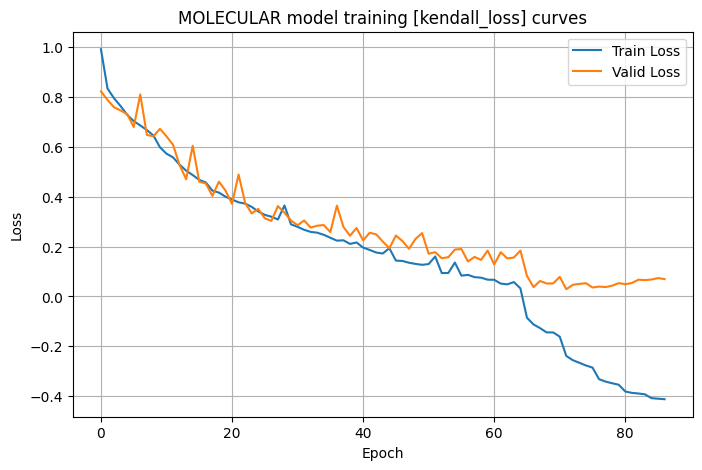

In [18]:
from geomml.losses.kendall import kendall_loss

qm9 = build_dataset("qm9", target_index=4)
esol = build_dataset("esol")
ogbg_molhiv = build_dataset("ogbg-molhiv")

dataset = build_dataset( # Получение --- Скачивание датасета
    "unified",
    datasets=[qm9, esol, ogbg_molhiv]
)

loaders = build_loaders( # Разделение train/val/test # Подготовка DataLoader'ов
    dataset, 
    batch_size=64,
    train_size=0.8,
    valid_size=0.1,
)

model = build_model("molecular", n_features=128)
optimizer = instantiate(cfg.optimizer, params=model.parameters())
scheduler = instantiate(cfg.scheduler, optimizer)

trainer = MultiTaskTrainer(
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    criterion=kendall_loss,
    device=get_device(),
    patience=15,
    min_delta=1e-4,
    best_model_pfx="kendall",
)

model, history = trainer.fit(
    train_loader=loaders.train,
    valid_loader=loaders.valid,
    num_epochs=1000
)

plot_history(history, title="MOLECULAR model training [kendall_loss] curves")

del optimizer, model, trainer, history, loaders, dataset, qm9, esol, ogbg_molhiv

# 4. Kendall + Prior loss
Попробуем теперь реализовать аккуратно и по-взрослому еще одну идею hybrid loss: Kendall uncertainty + “soft prior” multitask loss. 

Это должна быть реально сильная схема для кейса: QM9 + ESOL + HIV, поскольку она одновременно:
* адаптивно балансирует задачи (Kendall)
* не даёт одной задаче “улететь” (regularizer/anchor)
* стабилизирует обучение на смеси датасетов

## Общая идея в комбинации:
1. Kendall uncertainty weighting (основной механизм) - модель сама решает веса задач:
$$
L = \frac{1}{2\sigma^2} L_i + \log \sigma
$$
2. Multitask prior (стабилизатор) - фиксированная “якорная” версия **multitask_loss**: не доминирует, но удерживает баланс.
3. Итоговая формула
$$
L = L_{Kendall} + λ*L_{prior}, \\
λ∼0.05−0.2
$$



Dataset size: 173086

Epoch [   1/1000] | TrainLoss: 1.1027 | ValidLoss: 0.9119 | LR: 1.00e-03 | EarlyStop: 0 /15 | EpochTime: 42.77s
Epoch [   2/1000] | TrainLoss: 0.9307 | ValidLoss: 0.8630 | LR: 1.00e-03 | EarlyStop: 0 /15 | EpochTime: 26.32s
Epoch [   3/1000] | TrainLoss: 0.8894 | ValidLoss: 0.9196 | LR: 1.00e-03 | EarlyStop: 1 /15 | EpochTime: 26.14s
Epoch [   4/1000] | TrainLoss: 0.8479 | ValidLoss: 0.8342 | LR: 1.00e-03 | EarlyStop: 0 /15 | EpochTime: 25.46s
Epoch [   5/1000] | TrainLoss: 0.8157 | ValidLoss: 0.8169 | LR: 1.00e-03 | EarlyStop: 0 /15 | EpochTime: 25.58s
Epoch [   6/1000] | TrainLoss: 0.7797 | ValidLoss: 0.7796 | LR: 1.00e-03 | EarlyStop: 0 /15 | EpochTime: 24.88s
Epoch [   7/1000] | TrainLoss: 0.7538 | ValidLoss: 0.7896 | LR: 1.00e-03 | EarlyStop: 1 /15 | EpochTime: 26.43s
Epoch [   8/1000] | TrainLoss: 0.7197 | ValidLoss: 0.7508 | LR: 1.00e-03 | EarlyStop: 0 /15 | EpochTime: 26.60s
Epoch [   9/1000] | TrainLoss: 0.6834 | ValidLoss: 0.7475 | LR: 1.00e-03 | EarlyS

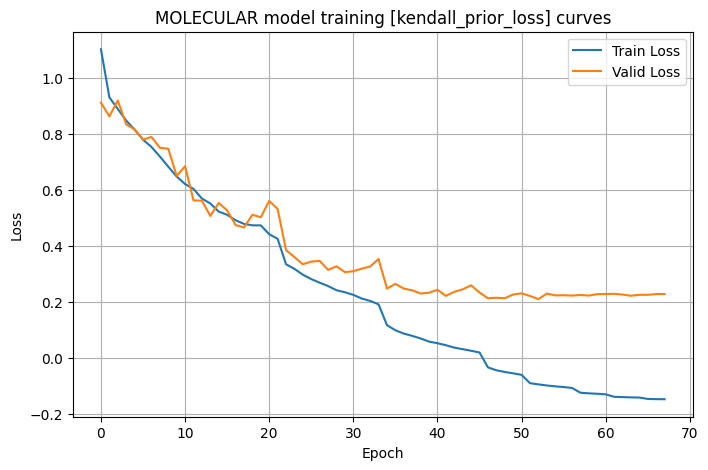

In [4]:
from geomml.losses.kendall_prior import kendall_prior_loss

qm9 = build_dataset("qm9", target_index=4)
esol = build_dataset("esol")
ogbg_molhiv = build_dataset("ogbg-molhiv")

dataset = build_dataset( # Получение --- Скачивание датасета
    "unified",
    datasets=[qm9, esol, ogbg_molhiv]
)

loaders = build_loaders( # Разделение train/val/test # Подготовка DataLoader'ов
    dataset, 
    batch_size=64,
    train_size=0.8,
    valid_size=0.1,
)

model = build_model("molecular", n_features=128)
optimizer = instantiate(cfg.optimizer, params=model.parameters())
scheduler = instantiate(cfg.scheduler, optimizer)

trainer = MultiTaskTrainer(
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    criterion=kendall_prior_loss,
    device=get_device(),
    patience=15,
    min_delta=1e-4,
    best_model_pfx="kendall_prior",
)

model, history = trainer.fit(
    train_loader=loaders.train,
    valid_loader=loaders.valid,
    num_epochs=1000
)

plot_history(history, title="MOLECULAR model training [kendall_prior_loss] curves")

del optimizer, model, trainer, history, loaders, dataset, qm9, esol, ogbg_molhiv

## Сравнительный анализ

Полученные результаты показывают, что обе функции потерь обеспечивают устойчивое обучение модели, однако их влияние на качество существенно различается.

Использование Kendall uncertainty loss позволило модели автоматически подобрать веса между задачами и достичь значительно лучшего качества на валидационной выборке. Минимальная ошибка оказалась примерно в 7 раз ниже, чем при использовании комбинированной функции потерь с prior (0.0293 против 0.2105).

Добавление регуляризующего слагаемого действительно сделало процесс обучения более плавным и ограничило изменение параметров неопределенности, однако одновременно уменьшило свободу адаптации весов отдельных задач. В результате оптимизация стала более консервативной, что привело к преждевременному выходу на плато и ухудшению итогового качества модели.

Таким образом, для рассматриваемой архитектуры и набора данных классическая функция Kendall uncertainty weighting оказалась более эффективной, чем её модификация с дополнительным prior. Хотя комбинированная функция обеспечивает более стабильное поведение процесса обучения, эта стабильность достигается ценой снижения качества решения задачи многозадачного обучения.

# 5. Модель **molecular_v1**

| Компонент              | molecular_v1                | molecular          |
| ---------------------- | ------------------------------ | ----------------------- |
| Геометрический энкодер | `GraphEncoder`                 | `SimpleGeomML`          |
| TDA                    | 256-мерный                     | 128-мерный + projection |
| Fusion                 | gate (learnable interpolation) | обычный MLP             |
| Task conditioning      | concat + projection            | сложение embedding      |
| Backbone               | Residual blocks                | отсутствует             |
| Heads                  | `ModuleDict` по задачам        | три отдельных head      |
| Loss                   | вынесен наружу                 | встроен в модель        |
| Base class             | `nn.Module`                    | `BaseModel`             |


Архитурно модель "molecular" выглядит более зрелой и модульной, чем "molecular_v1":
* отдельное кодирование атомов и координат;
* более мощный TDA-энкодер;
* адаптивное gate-слияние вместо простого MLP;
* residual-блоки после объединения признаков;
* task conditioning через конкатенацию и проекцию;
* широкое использование LayerNorm и SiLU;
* модульные головы через ModuleDict;
* разделение модели и функции потерь.

При этом есть важное ограничение, которое касается обеих версий "molecular" и "molecular_v1": геометрический энкодер не использует структуру графа. Он обрабатывает каждый атом независимо и затем делает global_mean_pool. Это означает, что модель не учитывает связи между атомами, соседей, расстояния между парами атомов и углы. Поэтому, несмотря на название GraphEncoder, это скорее per-atom MLP + pooling, а не полноценная графовая нейронная сеть. Если сравнивать с современными моделями для молекул (например, на основе message passing или геометрических GNN), именно это является главным архитектурным ограничением обеих реализаций.

In [5]:
from geomml.losses.kendall import kendall_loss

qm9 = build_dataset("qm9", target_index=4)
esol = build_dataset("esol")
ogbg_molhiv = build_dataset("ogbg-molhiv")

dataset = build_dataset( # Получение --- Скачивание датасета
    "unified",
    datasets=[qm9, esol, ogbg_molhiv]
)

loaders = build_loaders( # Разделение train/val/test # Подготовка DataLoader'ов
    dataset, 
    batch_size=64,
    train_size=0.8,
    valid_size=0.1,
)

model = build_model("molecular_v3", n_features=128)
optimizer = instantiate(cfg.optimizer, params=model.parameters())
scheduler = instantiate(cfg.scheduler, optimizer)

trainer = MultiTaskTrainer(
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    criterion=kendall_loss,
    device=get_device(),
    patience=15,
    min_delta=1e-4,
    best_model_pfx="kendall",
)

model, history = trainer.fit(
    train_loader=loaders.train,
    valid_loader=loaders.valid,
    num_epochs=1000
)

plot_history(history, title="MOLECULAR model training [kendall_loss] curves")

del optimizer, model, trainer, history, loaders, dataset, qm9, esol, ogbg_molhiv


Dataset size: 173086

Epoch [   1/1000] | 

KeyError: 'edge_index'


Dataset size: 173086

Epoch [   1/1000] | TrainLoss: 0.8714 | ValidLoss: 0.6427 | LR: 1.00e-03 | EarlyStop: 0 /15 | EpochTime: 51.63s
Epoch [   2/1000] | TrainLoss: 0.6363 | ValidLoss: 0.5640 | LR: 1.00e-03 | EarlyStop: 0 /15 | EpochTime: 27.08s
Epoch [   3/1000] | TrainLoss: 0.5290 | ValidLoss: 0.4905 | LR: 1.00e-03 | EarlyStop: 0 /15 | EpochTime: 27.35s
Epoch [   4/1000] | TrainLoss: 0.4574 | ValidLoss: 0.4004 | LR: 1.00e-03 | EarlyStop: 0 /15 | EpochTime: 27.74s
Epoch [   5/1000] | TrainLoss: 0.3943 | ValidLoss: 0.4194 | LR: 1.00e-03 | EarlyStop: 1 /15 | EpochTime: 27.82s
Epoch [   6/1000] | TrainLoss: 0.3515 | ValidLoss: 0.3959 | LR: 1.00e-03 | EarlyStop: 0 /15 | EpochTime: 27.74s
Epoch [   7/1000] | TrainLoss: 0.2963 | ValidLoss: 0.2524 | LR: 1.00e-03 | EarlyStop: 0 /15 | EpochTime: 27.13s
Epoch [   8/1000] | TrainLoss: 0.2501 | ValidLoss: 0.2011 | LR: 1.00e-03 | EarlyStop: 0 /15 | EpochTime: 27.14s
Epoch [   9/1000] | TrainLoss: 0.2332 | ValidLoss: 0.2303 | LR: 1.00e-03 | EarlyS

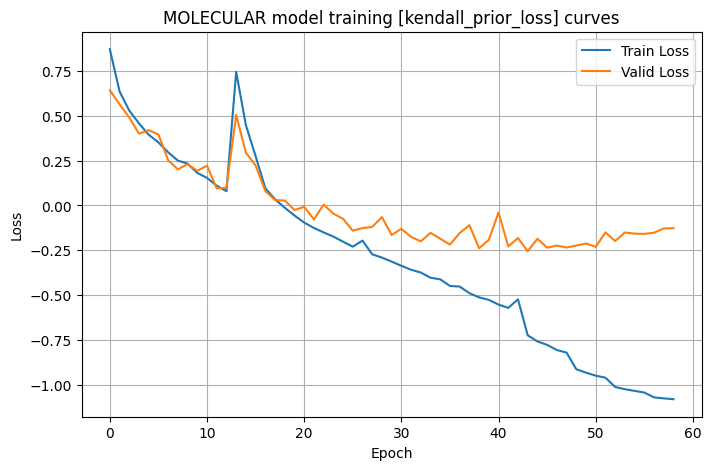

In [14]:
from geomml.losses.kendall import kendall_loss
from geomml.losses.kendall_prior import kendall_prior_loss

qm9 = build_dataset("qm9", target_index=4)
esol = build_dataset("esol")
ogbg_molhiv = build_dataset("ogbg-molhiv")

dataset = build_dataset( # Получение --- Скачивание датасета
    "unified",
    datasets=[qm9, esol, ogbg_molhiv]
)

loaders = build_loaders( # Разделение train/val/test # Подготовка DataLoader'ов
    dataset, 
    batch_size=64,
    train_size=0.8,
    valid_size=0.1,
)

model = build_model("molecular_v1", n_features=128)
optimizer = instantiate(cfg.optimizer, params=model.parameters())
scheduler = instantiate(cfg.scheduler, optimizer)

trainer = MultiTaskTrainer(
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    criterion=kendall_prior_loss,
    device=get_device(),
    patience=15,
    min_delta=1e-4,
    best_model_pfx="kendall",
)

model, history = trainer.fit(
    train_loader=loaders.train,
    valid_loader=loaders.valid,
    num_epochs=1000
)

plot_history(history, title="MOLECULAR model training [kendall_prior_loss] curves")

del optimizer, model, trainer, history, loaders, dataset, qm9, esol, ogbg_molhiv

По сути, первая модель — это **рефакторинг + архитектурное улучшение** второй. Идея одна и та же (геометрия + TDA + мультитаск), но реализована она иначе. Ниже — основные различия.

| Компонент              | Первая модель                  | Вторая модель           |
| ---------------------- | ------------------------------ | ----------------------- |
| Геометрический энкодер | `GraphEncoder`                 | `SimpleGeomML`          |
| TDA                    | 256-мерный                     | 128-мерный + projection |
| Fusion                 | gate (learnable interpolation) | обычный MLP             |
| Task conditioning      | concat + projection            | сложение embedding      |
| Backbone               | Residual blocks                | отсутствует             |
| Heads                  | `ModuleDict` по задачам        | три отдельных head      |
| Loss                   | вынесен наружу                 | встроен в модель        |
| Base class             | `nn.Module`                    | `BaseModel`             |

Теперь подробнее.

---

# 1. Geometry encoder

Во второй модели

```python
h = atom_emb(z)

x = torch.cat([h, pos], dim=-1)

h = mlp(x)
```

То есть координаты просто приписываются к эмбеддингу атома.

Это очень простой вариант.

---

В первой

```python
h_atom = atom_emb(z)

h_pos = coord_mlp(pos)

h = torch.cat([h_atom, h_pos])

h = fuse(h)
```

То есть сначала отдельно кодируется

* тип атома
* координаты

и только потом объединяются.

Это обычно работает лучше, потому что сеть сама учится извлекать признаки из координат.

---

# 2. Координаты

Во второй модели

```python
Linear(259 → 256)
```

Координаты входят в сеть "как есть".

---

В первой

```python
3
↓

256
↓

256
```

Получается полноценный embedding координат.

Это значительно богаче.

---

# 3. TDA encoder

Во второй

```python
128
↓

128
↓

project →256
```

То есть

```
TDA
↓

128

↓

128

↓

256
```

---

В первой

сразу

```
TDA

↓

256

↓

256
```

Проще и симметричнее относительно geometry.

---

# 4. Fusion

Это самое большое отличие.

Во второй

```python
h = fuse(cat(g, t))
```

где

```python
Linear

↓

SiLU

↓

Linear
```

То есть сеть должна заново построить всё представление.

---

В первой

используется gate

```python
α = sigmoid(W[g,t])

output = α*g + (1-α)*t
```

Это похоже на

* Highway Network
* GRU
* Mixture of Experts

То есть модель решает

> "сколько брать от геометрии,
> сколько от TDA".

Это намного стабильнее.

---

# 5. Task embedding

Во второй

```python
h = h + task_embedding
```

Обычное сложение.

---

В первой

```python
cat(h, task)

↓

projection
```

Это значительно гибче.

Модель может использовать task embedding нелинейно.

---

# 6. Backbone

Во второй

после fusion сразу

```
head
```

---

В первой

```
fusion

↓

Residual

↓

Residual

↓

head
```

То есть появляется настоящий общий feature extractor.

Это позволяет голове быть простой.

---

# 7. Residual

Во второй их нет.

В первой

```python
x = x + F(x)

LayerNorm
```

Это:

* глубже сеть
* лучше градиенты
* легче обучение.

---

# 8. Heads

Во второй

```python
head_y

head_dipole

head_polar
```

Жёстко прописаны.

---

В первой

```python
ModuleDict({
   "qm9": ...
   "esol": ...
   "molhiv": ...
})
```

То есть модель не зависит от конкретных задач.

Можно добавить

```python
"tox21"
```

без изменения forward.

---

# 9. Возвращаемое значение

Во второй

```python
{
 "repr": h,
 "y": ...,
 ...
}
```

---

В первой

```python
{
 "qm9": ...,
 "esol": ...,
 "molhiv": ...
}
```

То есть ориентирована на мультидатасет.

---

# 10. Loss

Во второй

внутри модели есть

```python
loss_fn(...)
```

---

В первой

его вообще нет.

Значит

Trainer

или

Lightning

сам считает loss.

Это более современная архитектура.

---

# 11. Наследование

Во второй

```python
class MolecularModel(BaseModel)
```

В первой

```python
class MolecularModel(nn.Module)
```

То есть первая почти не зависит от инфраструктуры.

---

# 12. Нормализация

Во второй почти нет нормализации.

В первой

есть

```python
LayerNorm
```

в

* GraphEncoder
* TDA
* Project
* Residual

Это обычно сильно помогает при мультитасковом обучении.

---

# 13. Dropout

Во второй отсутствует.

В первой

```python
Dropout(0.1)
```

в TDA.

---

# 14. Активации

Во второй

```
ReLU
```

в TDA.

В первой

везде

```
SiLU
```

SiLU обычно предпочтительнее для регрессии и непрерывных признаков.

---

# Итог

Архитурно первая модель выглядит более зрелой и модульной:

* отдельное кодирование атомов и координат;
* более мощный TDA-энкодер;
* адаптивное gate-слияние вместо простого MLP;
* residual-блоки после объединения признаков;
* task conditioning через конкатенацию и проекцию;
* широкое использование `LayerNorm` и `SiLU`;
* модульные головы через `ModuleDict`;
* разделение модели и функции потерь.

При этом есть важное ограничение, которое касается обеих версий: **геометрический энкодер не использует структуру графа**. Он обрабатывает каждый атом независимо и затем делает `global_mean_pool`. Это означает, что модель **не учитывает связи между атомами, соседей, расстояния между парами атомов и углы**. Поэтому, несмотря на название `GraphEncoder`, это скорее **per-atom MLP + pooling**, а не полноценная графовая нейронная сеть. Если сравнивать с современными моделями для молекул (например, на основе message passing или геометрических GNN), именно это является главным архитектурным ограничением обеих реализаций.


# 5. Модель **molecular_v2**

In [9]:
from geomml.losses.kendall import kendall_loss

qm9 = build_dataset("qm9", target_index=4)
esol = build_dataset("esol")
ogbg_molhiv = build_dataset("ogbg-molhiv")

dataset = build_dataset( # Получение --- Скачивание датасета
    "unified",
    datasets=[qm9, esol, ogbg_molhiv]
)

loaders = build_loaders( # Разделение train/val/test # Подготовка DataLoader'ов
    dataset, 
    batch_size=64,
    train_size=0.8,
    valid_size=0.1,
)

model = build_model("molecular_v2", n_features=128)
optimizer = instantiate(cfg.optimizer, params=model.parameters())
scheduler = instantiate(cfg.scheduler, optimizer)

trainer = MultiTaskTrainer(
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    criterion=kendall_loss,
    device=get_device(),
    patience=15,
    min_delta=1e-4,
    best_model_pfx="kendall",
)

model, history = trainer.fit(
    train_loader=loaders.train,
    valid_loader=loaders.valid,
    num_epochs=1000
)

plot_history(history, title="MOLECULAR model training [kendall_loss] curves")

del optimizer, model, trainer, history, loaders, dataset, qm9, esol, ogbg_molhiv


Dataset size: 173086

Epoch [   1/1000] | 

ValueError: too many values to unpack (expected 2)

ВАРИАНТ 2 — GradNorm (более мощный, но сложнее)

Если хочешь “research-grade” балансировку.

💡 Идея

Балансирует задачи по скорости обучения градиентов, а не по loss.

🧠 Нужно хранить:
initial losses
текущие loss ratios
gradient norms
⚠️ Реальность

GradNorm:

сложнее
требует hooks / backward hooks
чуть медленнее
может нестабильно себя вести на малых batch
💬 честная рекомендация
Метод	когда использовать
Uncertainty weighting	⭐ почти всегда (твоя ситуация)
GradNorm	если 3+ задач и сильный дисбаланс
🧭 Что я бы сделал на твоём месте

👉 100% start с uncertainty weighting
👉 потом, если захочешь research-апгрейд — GradNorm

🚀 Если хочешь дальше усилить модель

Я могу тебе добавить:

1. adaptive task sampling (очень мощно)
2. cosine-balanced losses
3. gradient surgery (PCGrad) — топ для конфликтующих задач
4. task-specific heads + shared trunk redesign (как в NeurIPS multitask papers)

Сейчас у тебя уже уровень “нормального research pipeline”, просто нужно стабилизировать обучение — uncertainty weighting это именно тот фикс.

In [ ]:
# model = build_model("molecular_v2", n_features=128)
# model = build_model("egnn_molecular")

trainer = UnifiedTrainer(
    model=model,
    optimizer=optimizer,
    loss_fn_dict={
        "y": F.mse_loss,
        "dipole": F.mse_loss,
        "polar": F.mse_loss,
    },
    device=get_device()
)

for epoch in range(5):

    model.train()

    total_loss = 0.0
    total_logs = {}

    for batch in loaders.train:

        # перенос на устройство
        batch = batch.to(get_device())   # если batch - PyG Batch

        # если batch - dict, то вместо строки выше:
        # batch = {k: v.to(get_device()) if torch.is_tensor(v) else v
        #          for k, v in batch.items()}

        pred = model(batch)

        loss = 0.0
        logs = {}

        for key, loss_fn in {
            "y": F.mse_loss,
            "dipole": F.mse_loss,
            "polar": F.mse_loss,
        }.items():

            if key not in batch or key not in pred:
                continue

            y_true = batch[key]
            y_pred = pred[key]

            l = loss_fn(y_pred, y_true)

            loss += l
            logs[key] = l.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        logs["loss"] = loss.item()

        total_loss += loss.item()

        for k, v in logs.items():
            total_logs[k] = total_logs.get(k, 0.0) + v

    # усреднение по эпохе
    num_batches = len(loaders.train)

    for k in total_logs:
        total_logs[k] /= num_batches

    print(f"Epoch {epoch}: {total_logs}")

Если рассматривать все три модели как эволюцию одной идеи, то получается довольно понятная последовательность.

| Компонент                        | **Модель 1 (`molecular_v1`)**            | **Модель 2 (`molecular`)**             | **Модель 3 (`molecular_v2`)**                              |
| -------------------------------- | ---------------------------------------- | -------------------------------------- | ---------------------------------------------------------- |
| Геометрический энкодер           | `GraphEncoder` (MLP по атомам + pooling) | `SimpleGeomML`                         | **GINEConv (настоящий графовый энкодер)**                  |
| Использование графовой структуры | ❌ нет                                    | ❌ нет                                  | ✅ `edge_index` + message passing                           |
| Использование координат          | отдельный `coord_mlp`                    | координаты конкатенируются с embedding | координаты используются как признаки рёбер (`pos_i-pos_j`) |
| Взаимодействие атомов            | отсутствует                              | отсутствует                            | есть через несколько слоёв GINE                            |
| TDA                              | 256-мерный                               | 128-мерный + projection                | 256-мерный                                                 |
| Fusion                           | gate (learnable interpolation)           | обычный MLP                            | gate (learnable interpolation)                             |
| Task conditioning                | concat + projection                      | сложение embedding                     | concat + projection                                        |
| Backbone                         | 2 Residual блока                         | отсутствует                            | 2 Residual блока                                           |
| Heads                            | `ModuleDict` по задачам/датасетам        | три отдельных head                     | `ModuleDict` по предсказаниям                              |
| Нормализация                     | LayerNorm почти везде                    | практически отсутствует                | LayerNorm почти везде                                      |
| Dropout                          | есть                                     | нет                                    | есть                                                       |
| Loss                             | вынесен наружу                           | встроен в модель                       | вынесен наружу                                             |
| Base class                       | `nn.Module`                              | `BaseModel`                            | `nn.Module`                                                |
| Масштабируемость                 | высокая                                  | низкая                                 | высокая                                                    |
| Архитектурная сложность          | средняя                                  | низкая                                 | высокая                                                    |

---

# Сравнение моделей

## Модель 2 (`molecular`) — базовая

Это самая простая архитектура.

Геометрический энкодер фактически делает

```
атом
↓

Embedding

+

координаты

↓

MLP

↓

mean pooling
```

Каждый атом обрабатывается независимо.

После этого признаки всех атомов просто усредняются.

То есть модель вообще не знает

* какие атомы соединены;
* кто чей сосед;
* какие существуют химические связи.

Из-за этого она ближе к обычной MLP, чем к GNN.

Достоинства:

* простая;
* быстро обучается;
* мало параметров.

Недостатки:

* не использует структуру молекулы;
* слабая выразительность;
* встроенный `loss_fn` делает модель менее универсальной.

---

# Модель 1 (`molecular_v1`)

Это уже серьёзный шаг вперёд.

Появились:

* отдельный encoder координат;
* LayerNorm;
* SiLU;
* residual backbone;
* gate fusion;
* модульные головы;
* task conditioning через concat.

То есть архитектура стала значительно современнее.

Однако главный недостаток сохранился.

Несмотря на название `GraphEncoder`, графа внутри нет.

Каждый атом кодируется отдельно

```
atom

↓

Embedding

coord

↓

MLP

↓

concat

↓

MLP
```

после чего

```
global_mean_pool
```

Никакого обмена сообщениями между атомами нет.

Поэтому химическая структура молекулы по-прежнему игнорируется.

---

# Модель 3 (`molecular_v2`)

Это уже полноценная графовая нейронная сеть.

Главное отличие —

```
GINEConv
```

Теперь признаки атомов обновляются с учётом соседей.

То есть вычисляется примерно

```
h_i^{k+1}

=

MLP(

h_i

+

Σ message(h_j,e_ij)

)
```

где сообщения приходят от соседних атомов.

Именно этого не хватало первым двум моделям.

---

Кроме того появились признаки рёбер.

Вместо

```
coord_mlp(pos)
```

используется

```
edge_attr

=

pos_i-pos_j
```

что соответствует относительной геометрии.

Относительные координаты обычно намного информативнее абсолютных.

---

Далее архитектура почти совпадает с первой моделью:

```
Graph

↓

Fusion

↓

Task embedding

↓

Residual

↓

Heads
```

То есть фактически

```
v1

+

настоящий GNN
```

---

# Основные архитектурные отличия

## Геометрический энкодер

### Модель 2

```
атом

↓

MLP

↓

pool
```

---

### Модель 1

```
атом

↓

Embedding

координаты

↓

MLP

↓

fusion

↓

pool
```

---

### Модель 3

```
атом

↓

Embedding

↓

GINE

↓

GINE

↓

GINE

↓

GINE

↓

pool
```

Это уже полноценное извлечение структурных признаков.

---

## Использование координат

Во второй модели

```
(atom embedding, xyz)
```

просто конкатенируются.

---

В первой

координаты проходят собственную нейросеть.

---

В третьей

координаты используются для вычисления

```
edge_attr

=

pos_i-pos_j
```

что намного ближе к современным геометрическим GNN.

---

## Использование структуры молекулы

Это самое важное отличие.

Модель 2

```
C

O

H

H

↓

независимо
```

---

Модель 1

точно так же

```
C

O

H

H

↓

независимо
```

---

Модель 3

```
C —— O
 \
  H
 \
  H
```

структура графа реально участвует в вычислениях.

---

## Fusion

Модели 1 и 3 используют

```
α=g(g,t)

output

=

αg+(1−α)t
```

Это позволяет модели самой решать,

насколько доверять

* геометрии;
* топологическим признакам.

Во второй модели этого нет.

---

## Backbone

Во второй модели

```
Fusion

↓

Head
```

---

В первой и третьей

```
Fusion

↓

Residual

↓

Residual

↓

Head
```

что позволяет разделить

общее представление

и

специализированные головы.

---

# Выразительность моделей

Если расположить модели по способности описывать молекулу, получится следующая последовательность:

```
Модель 2
(SimpleGeomML)

        ↓

Модель 1
(лучший encoder + fusion + backbone)

        ↓↓↓

Модель 3
(GINE + edge features + backbone)
```

Переход **от модели 2 к модели 1** — это в основном улучшение инженерной реализации и обучения: более качественное кодирование координат, нормализация, residual-блоки, адаптивное слияние признаков и модульная организация.

Переход **от модели 1 к модели 3** — уже качественное изменение самой модели. Если первые две архитектуры можно рассматривать как MLP над атомными признаками с последующим усреднением, то третья становится настоящей графовой нейронной сетью, в которой признаки каждого атома зависят от его химического окружения. Именно это обычно даёт наибольший прирост качества на большинстве молекулярных задач, поскольку позволяет учитывать локальную структуру молекулы, а не только независимые свойства отдельных атомов.


#============================================================================================================================================

# реализуй полноценный пайплайн с нуля для этой архитектуры
```mermaid
flowchart TB

subgraph Geometry
    A[Atomic Numbers and Coordinates]
    B[EGNN / GeomML Encoder]
    C[Geometric Embedding 256-d]

    A --> B --> C
end

subgraph Topology
    D[Persistent Diagrams]
    E[PersLay / Persistence Image]
    F[Topological Embedding 128-d]

    D --> E --> F
end

C --> G[Cross Attention]
F --> G

G --> H[Feature Fusion]
H --> I[Fusion MLP]

I --> J[Dipole Moment]
I --> K[Polarizability Tensor]
```

Ниже — полноценный end-to-end PyTorch пайплайн под твою архитектуру (GeomML + TDA + Cross-Attention + multi-task heads). Я сделаю его так, чтобы он был:

реально обучаемый
расширяемый (как в research code)
совместим с PyTorch Geometric / обычным PyTorch
без “магии”, но с правильной структурой


## 1. Общая идея пайплайна
```
Atoms (z, pos)
      │
      ├── Geometry branch → EGNN → h_geom (256)
      │
      ├── Topology branch → TDA → h_tda (128)
      │
      ├── Cross-Attention
      │
      ├── Fusion MLP
      │
      ├── Dipole head (3)
      │
      └── Polarizability head (6)
```
## 2. Зависимости

## 3. Dataset (Alchemy-style)

In [ ]:

class MoleculeDataset(Dataset):
    def __init__(self, data):
        """
        data: list of dicts:
        {
            z: (N,),
            pos: (N,3),
            tda: (128,),
            dipole: (3,),
            polar: (6,)
        }
        """
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        return (
            torch.tensor(item["z"], dtype=torch.long),
            torch.tensor(item["pos"], dtype=torch.float),
            torch.tensor(item["tda"], dtype=torch.float),
            torch.tensor(item["dipole"], dtype=torch.float),
            torch.tensor(item["polar"], dtype=torch.float),
        )

In [ ]:
# Диполь + поляризуемость

class DipolePolarTask(Task):

    def __init__(
        self,
        dipole_weight=1.0,
        polar_weight=1.0,
    ):
        self.criterion = nn.MSELoss()
        self.dipole_weight = dipole_weight
        self.polar_weight = polar_weight



    @torch.no_grad()
    def metrics(self, outputs, batch):

        return {
            "dipole_mae": torch.mean(
                torch.abs(
                    outputs["dipole"] - batch["dipole"]
                )
            ).item(),

            "polar_mae": torch.mean(
                torch.abs(
                    outputs["polar"] - batch["polar"]
                )
            ).item(),
        }

In [ ]:
# Для задачи диполя и поляризуемости

task = DipolePolarTask(
    dipole_weight=1.0,
    polar_weight=0.5,
)

In [ ]:
class DipolePolarTask(Task):

    def __init__(self, dipole_weight=1.0, polar_weight=1.0):
        self.criterion = nn.MSELoss()
        self.dipole_weight = dipole_weight
        self.polar_weight = polar_weight

    def loss(self, outputs, batch):

        loss_d = self.criterion(
            outputs["dipole"],
            batch["dipole"],
        )

        loss_p = self.criterion(
            outputs["polar"],
            batch["polar"],
        )

        return (
            self.dipole_weight * loss_d
            + self.polar_weight * loss_p
        )

    @torch.no_grad()
    def metrics(self, outputs, batch):

        return {
            "dipole_mae": torch.mean(
                torch.abs(outputs["dipole"] - batch["dipole"])
            ).item(),

            "polar_mae": torch.mean(
                torch.abs(outputs["polar"] - batch["polar"])
            ).item(),
        }

In [ ]:
# для диполя:
task = DipolePolarTask(
    dipole_weight=1.0,
    polar_weight=0.5,
)

## 📉 9. Loss function (multi-task)

In [ ]:
import torch.nn.functional as F

def loss_fn(pred_dipole, pred_polar, y_dipole, y_polar):
    loss_dipole = F.mse_loss(pred_dipole, y_dipole)
    loss_polar = F.mse_loss(pred_polar, y_polar)

    return loss_dipole + 0.5 * loss_polar

## ⚙️ 10. Training loop

In [ ]:
def train_epoch(model, loader, optim, device):
    model.train()

    total_loss = 0

    for z, pos, tda, dipole, polar in loader:
        z, pos, tda = z.to(device), pos.to(device), tda.to(device)
        dipole, polar = dipole.to(device), polar.to(device)

        pred_d, pred_p = model(z, pos, tda)

        loss = loss_fn(pred_d, pred_p, dipole, polar)

        optim.zero_grad()
        loss.backward()
        optim.step()

        total_loss += loss.item()

    return total_loss / len(loader)

## 📊 11. Evaluation

In [ ]:
@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()

    total = 0

    for z, pos, tda, dipole, polar in loader:
        z, pos, tda = z.to(device), pos.to(device), tda.to(device)
        dipole, polar = dipole.to(device), polar.to(device)

        pred_d, pred_p = model(z, pos, tda)

        loss = loss_fn(pred_d, pred_p, dipole, polar)
        total += loss.item()

    return total / len(loader)

## 🔁 12. Training pipeline

In [ ]:
device = "cuda"

model = MolecularModel().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

for epoch in range(50):
    train_loss = train_epoch(model, train_loader, optimizer, device)
    val_loss = evaluate(model, val_loader, device)

    print(f"Epoch {epoch}: train={train_loss:.4f}, val={val_loss:.4f}")

## получилось:

🔬 Geometry branch
* EGNN / GeomML

🧬 Topology branch
* TDA (PersLay)

⚡ Fusion
* Cross-Attention

🎯 Multi-task outputs
* Dipole (vector)
* Polarizability (tensor)

## следующий уровень:

🔥 1. “NeurIPS-grade model”
* real EGNN message passing
* multi-head attention
* equivariant features

🔥 2. “Production-ready”
* PyTorch Lightning version
* logging + checkpoints + early stopping

🔥 3. “Paper version”
* ablation studies + diagrams + loss analysis

equivariant neural network + differentiable TDA (real SOTA version)

Почему почти нет работ со смешиванием?

Есть объективная причина.

Хотя свойства называются одинаково,

расчёты выполнялись разными пайплайнами;
распределения молекул отличаются;
есть систематические смещения даже для одинаковых свойств.

Это отмечается и в DeepMoleNet: например, корреляция между предсказаниями, обученными на QM9, и значениями Alchemy сильно различается по свойствам (для свободной энергии почти идеальна, а для дипольного момента заметно хуже).

Поэтому исследователи обычно предпочитают:

pretraining на одном датасете;
fine-tuning на другом;

вместо простого объединения.

Но можно ли это сделать?

Да, и здесь начинается интересная исследовательская задача.

В вашей архитектуре уже есть:

общий GraphEncoder;
task_embedding;
разные головы;
маски для отсутствующих таргетов.

Это очень похоже на архитектуры для multi-dataset learning.

То есть можно построить обучение вида

QM9 --------\
             \
              GraphEncoder
             /
Alchemy -----/

           ↓
       task embedding

      ↙            ↘
 QM9 heads      Alchemy heads

Насколько мне известно, это не является стандартным бенчмарком, и именно поэтому такая работа может представлять исследовательский интерес.

Если цель — публикация

Я бы пошёл ещё дальше и вместо смеси только QM9+Alchemy рассмотрел унифицированное обучение сразу на нескольких квантово-химических датасетах (QM9, Alchemy, ANI-1x, QMugs и др.) с общим геометрическим энкодером и датасет-специфическими головами. Это направление уже ближе к современным работам по фундаментальным моделям для атомистических систем. Например, модель JMP (Joint Multi-domain Pre-training) обучается одновременно на нескольких крупных квантово-химических наборах данных с общей моделью и отдельными задачами, а затем дообучается на QM9, rMD17 и других бенчмарках.

https://arxiv.org/abs/2310.16802